In [1]:
%matplotlib widget

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
spectrum_1 = pd.read_csv("Spectrum2s_1_gas_exp.csv")
spectrum_2 = pd.read_csv("Spectrum2s_2_gas_exp.csv")
spectrum_3 = pd.read_csv("Spectrum2s_3_gas_exp.csv")
spectrum_4 = pd.read_csv("Spectrum2s_4_gas_exp.csv")

In [4]:
spectrum_1

,Name,Flux,Error_flux
0,Hgamma,16.857888,4.652353
1,Hbeta,39.088569,3.823329
2,Halpha,125.531235,4.740519
3,[SII]6731_d1,4.620887,4.694302
4,[SII]6731_d2,17.735385,4.997104
5,HeII4687,0.449370,3.003074
6,HeI5876,5.031068,1.991278
7,[OIII]4959,15.802979,1.221058
8,[OIII]5007,47.408936,3.663175
9,[OI]6300,1.341684,1.489513


In [5]:
def K03(x):
    # AGN selection based on Kauffman et al. 2003
    # log OIII/Hb > 0.61/(log NII/Ha - 0.05) + 1.3
    return 0.61/(x - 0.05) + 1.3

def K01(x):
     # AGN selection based on Kewley et al. 2001
     # log OIII/Hb > 0.61/(log NII/Ha - 0.47) + 1.19
     return 0.61/(x - 0.47) + 1.19

def S06(x):
    # AGN selection based on Stasinska et al 2006
     # log OIII/Hb > 0.29/(log NII/Ha +0.20) + 0.96
    return 0.29/(x + 0.20) + 0.96

def C10(x):
 # AGN selection based on Cid Fernandes et al 2010
    return 1.01*x + 0.48

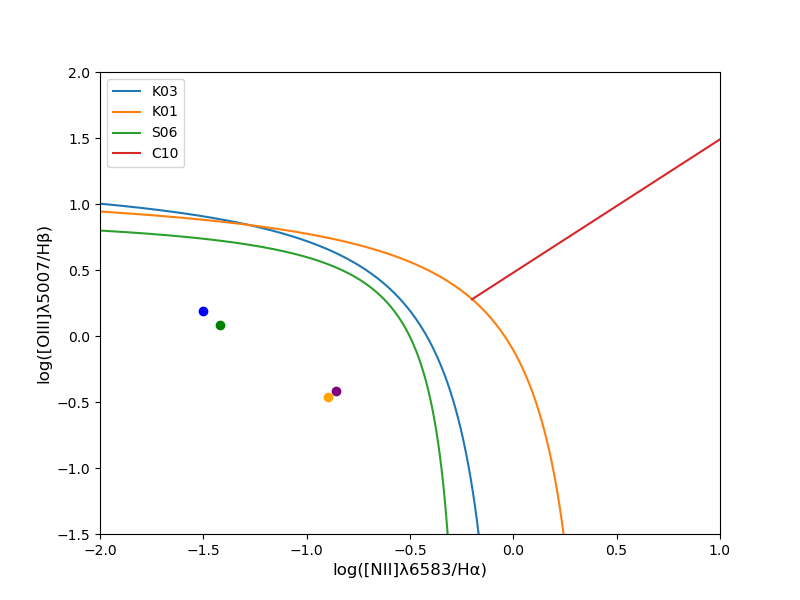

In [6]:
plt.figure(figsize=(8,6))

OIII_HB_1 = spectrum_1['Flux'][8]/spectrum_1['Flux'][1]
NII_HA_1 = spectrum_1['Flux'][12]/spectrum_1['Flux'][2]

OIII_HB_2 = spectrum_2['Flux'][8]/spectrum_2['Flux'][1]
NII_HA_2 = spectrum_2['Flux'][12]/spectrum_2['Flux'][2]

OIII_HB_3 = spectrum_3['Flux'][8]/spectrum_3['Flux'][1]
NII_HA_3 = spectrum_3['Flux'][12]/spectrum_3['Flux'][2]

OIII_HB_4 = spectrum_4['Flux'][8]/spectrum_4['Flux'][1]
NII_HA_4 = spectrum_4['Flux'][12]/spectrum_4['Flux'][2]

plt.scatter(np.log(NII_HA_1), np.log(OIII_HB_1), color = 'blue')
plt.scatter(np.log(NII_HA_2), np.log(OIII_HB_2), color = 'green')
plt.scatter(np.log(NII_HA_3), np.log(OIII_HB_3), color = 'purple')
plt.scatter(np.log(NII_HA_4), np.log(OIII_HB_4), color = 'orange')

x = np.linspace(-2, 0.04, num=200)
x1 = np.linspace(-2, 0.457, num=200)
x2 = np.linspace(-2, -0.25, num=200)
x3 = np.linspace(-0.2, 5, num=200)
plt.plot(x, K03(x), label = 'K03')
plt.plot(x1, K01(x1), label = 'K01')
plt.plot(x2, S06(x2), label = 'S06')
plt.plot(x3, C10(x3), label = 'C10')
plt.xlim(-2, 1)
plt.ylim(-1.5, 2)
plt.xlabel('log([NII]λ6583/Hα)', fontsize=12)
plt.ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
plt.legend()
plt.savefig('BPT_2s', bbox_inches='tight')